In [2]:
import torch
import torch.nn as nn
import merlin as ML

from tqdm import tqdm
import numpy as np

from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

import perceval as pcvl

Loading the dataset
---

In [3]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
size_of_dataset = 7000
X, y = mnist['data'][:size_of_dataset], mnist['target'][:size_of_dataset]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/7, stratify=y)
X_train.shape, X_test.shape, y_train.shape


((6000, 784), (1000, 784), (6000,))

In [4]:
# dimensionality reduction using PCA
from sklearn.decomposition import PCA

d = 8
pca = PCA(n_components=d) 
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
print('Explained variance', sum(pca.explained_variance_ratio_))

Explained variance 0.4467471420761513


In [5]:
# scaling the data for the quantum layer (must be in [0,1])
scaler = MinMaxScaler()
X_train = torch.tensor(scaler.fit_transform(X_train), dtype=torch.float32)
X_test = torch.tensor(scaler.transform(X_test), dtype=torch.float32)
y_train, y_test = torch.tensor(y_train.cat.codes.values, dtype=torch.long), torch.tensor(y_test.cat.codes.values, dtype=torch.long)

Linear Probing
---

In [6]:
# creating a baseline on the dimensionaly reduced dataset using linear regression
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(solver='lbfgs', max_iter=300)
clf.fit(X_train, y_train)

# Make predictions
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)
# Evaluate accuracy
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"train Accuracy: {train_accuracy:.3f} test Accuracy: {test_accuracy:0.3f}")

train Accuracy: 0.784 test Accuracy: 0.771


Quantum part
---

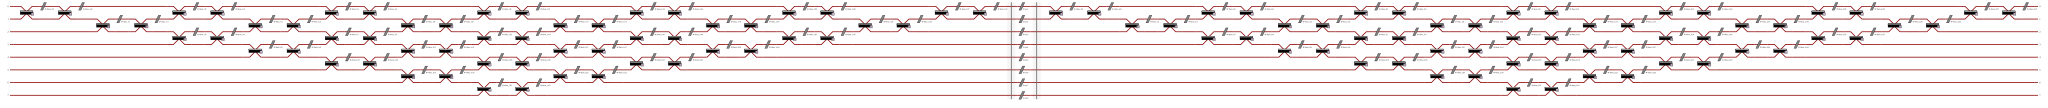

In [7]:
def create_circuit(m, d, depth):
    # m: number of modes
    # d: input dimension, d <= m
    # depth: number of layers
    
    c = pcvl.Circuit(m)

    # first layer
    w = pcvl.GenericInterferometer(m,
                                            lambda i: pcvl.BS() // pcvl.PS(pcvl.P(f"theta_{0}i{i}")) // \
                                                      pcvl.BS() // pcvl.PS(pcvl.P(f"theta_{0}o{i}")),
                                            shape=pcvl.InterferometerShape.TRIANGLE)
        
    # data encoding
    c_var = pcvl.Circuit(m)
    c_var.add(0, pcvl.Barrier(m), merge=True)
    for i in range(d):
        px = pcvl.P(f"px{i + 1}")
        c_var.add(i + (m - d) // 2, pcvl.PS(px))
    c_var.add(0, pcvl.Barrier(m), merge=True)

    # inputs
    params = c_var.get_parameters()
    
    for j in range(1, depth):
        # circuit creation
        w = pcvl.GenericInterferometer(m,
                                            lambda i: pcvl.BS() // pcvl.PS(pcvl.P(f"theta_{j}i{i}")) // \
                                                      pcvl.BS() // pcvl.PS(pcvl.P(f"theta_{j}o{i}")),
                                            shape=pcvl.InterferometerShape.TRIANGLE)
        
        # data encoding
        c_var = pcvl.Circuit(m)
        c_var.add(0, pcvl.Barrier(m), merge=True)
        for i in range(d):
            px = params[i]
            c_var.add(i + (m - d) // 2, pcvl.PS(px))
        c_var.add(0, pcvl.Barrier(m), merge=True)
       
        c.add(0, w, merge=True)
        c.add(0, c_var, merge=True)

    # last layer
    w = pcvl.GenericInterferometer(m,
                                            lambda i: pcvl.BS() // pcvl.PS(pcvl.P(f"theta_{depth}i{i}")) // \
                                                      pcvl.BS() // pcvl.PS(pcvl.P(f"theta_{depth}o{i}")),
                                            shape=pcvl.InterferometerShape.TRIANGLE)
    c.add(0, w, merge=True)
    return c

m = d
c = create_circuit(m=m, d=d, depth=2)
pcvl.pdisplay(c)

In [8]:
# concatenate features
class hybridModel(nn.Module):
    def __init__(self, m, d):
        super().__init__()
        self.n_classes = 10
        
        self.depth = 2
        self.circuit = create_circuit(m, d, self.depth)
        self.thetas = [p.name for p in self.circuit.get_parameters() if not p.name.startswith("px")]
        input_state = [1, 0] * (m // 2) + [0] * (m % 2)
        self.input_state = pcvl.BasicState(input_state)
        self.q_output_dim = 10
        self.qlayer = ML.QuantumLayer(
                        input_size=d,
                        output_size=self.q_output_dim,
                        circuit=self.circuit,
                        trainable_parameters=["theta"],                            # Which parameters to train
                        input_parameters=["px"],
                        # trainable_parameters=self.thetas,
                        no_bunching=True,
                        input_state = self.input_state,
                        output_mapping_strategy=ML.OutputMappingStrategy.GROUPING)
        self.hidden_dim = 100
        self.clayer = nn.Linear(d, self.hidden_dim)
        self.post_proc = nn.Linear(self.q_output_dim + self.hidden_dim, self.n_classes)

    def forward(self, x):
        x_c = F.relu(self.clayer(x)) # shape [batch_size, dim=10]
        x_q = self.qlayer(x) # shape [batch_size, dim=10]
        x_cat = torch.cat((x_c, x_q), dim=1)
        x = self.post_proc(x_cat)
        return x

    

model = hybridModel(m, d)
print('Number of Pytorch parameters', sum(p.numel() for p in model.parameters() if p.requires_grad) )

Number of Pytorch parameters 2122


Fully quantum model
---

In [9]:
class qlayer(nn.Module):
    def __init__(self, m, d):
        super().__init__()

        self.circuit = create_circuit(m, d, depth=2)
        self.thetas = [p.name for p in self.circuit.get_parameters() if not p.name.startswith("px")]
        self.input_state = [1, 0] * (m // 2) + [0] * (m % 2)
        self.q_output_dim = 10
        self.qlayer = ML.QuantumLayer(
                    input_size=d,
                    output_size=10,
                    circuit=self.circuit,
                    trainable_parameters=["theta"],                            # Which parameters to train
                    input_parameters=["px"],
                    no_bunching=True,
                    input_state = self.input_state,
                    output_mapping_strategy=ML.OutputMappingStrategy.GROUPING)
        
        self.num_classes = 10
        self.post_proc = nn.Linear(self.q_output_dim, self.num_classes)

    def forward(self, x):
        x = self.qlayer(x)
        x = self.post_proc(x)
        return x

MLP baseline
---

In [10]:
# classical baseline mlp model
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class MnistMLP(nn.Module):
    def __init__(self, input_shape=d, hidden_layers=64, num_classes=10):
        super().__init__()
        
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.n_hidden = hidden_layers
        self.l1 = nn.Linear(self.input_shape, self.n_hidden)
        self.l2 = nn.Linear(self.n_hidden, self.num_classes)

    def forward(self, x):
        z = F.relu(self.l1(x))
        z = self.l2(z)
        return z

In [11]:
def training(model, trainloader, testloader, n_epochs, batch_size, lr, verbose=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    pbar = tqdm(range(n_epochs), disable=not verbose)
    train_accuracies = []
    test_accuracies = []

    # before training
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    train_epoch_acc, test_epoch_acc = [], []
    with torch.no_grad():
        for batch_X, batch_y in testloader:
            train_outputs = model(batch_X)
            train_preds = torch.argmax(train_outputs, dim=1).numpy()
            train_acc = accuracy_score(batch_y.numpy(), train_preds)
            
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

        train_accuracies.append(train_acc)
        test_accuracies.append(correct/total)
    
    for epoch in pbar:
        model.train()
        train_loss = 0
        for batch_X, batch_y in trainloader:
            # Zero the gradients
            optimizer.zero_grad()
    
            # Forward pass
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
    
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
    
            train_loss += loss.item()
    
        # Validation
        model.eval()
        test_loss = 0
        correct = 0
        total = 0
        train_epoch_acc, test_epoch_acc = [], []
        with torch.no_grad():
            for batch_X, batch_y in testloader:
                train_outputs = model(X_train)
                train_preds = torch.argmax(train_outputs, dim=1).numpy()
                train_acc = accuracy_score(y_train.numpy(), train_preds)
                
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                test_loss += loss.item()
    
                _, predicted = torch.max(outputs.data, 1)
                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item()
                

        train_accuracies.append(train_acc)
        test_accuracies.append(correct/total)
        if verbose:
            print(f'Train Loss: {train_loss / len(trainloader):.4f} | '
                  f'Train Acc: {train_acc*100:.2f}% | '
                  f'Test Loss: {test_loss / len(testloader):.4f} | '
                  f'Test Acc: {100 * correct / total:.2f}%')
        
    return np.array(train_accuracies), np.array(test_accuracies)

In [12]:
# takes a long time to execute
from torch.utils.data import TensorDataset, DataLoader

# hyperparameters
n_epochs = 5
batch_size = 64
lr = 0.01
m = 8
d = 8

# dataloaders
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


# tracking accuracies
hybrid_accs = []
classic_accs = []
qlayer_accs = []

n_runs = 5
for i in tqdm(range(n_runs)):
    hybrid_model = hybridModel(m, d)
    mlp = MnistMLP(input_shape=d, hidden_layers=120, num_classes=10)
    q_model = qlayer(m, d)
    
    _, hybrid_test_acc = training(hybrid_model, train_loader, test_loader, n_epochs, batch_size, lr)
    _, qlayer_test_acc = training(q_model, train_loader, test_loader, n_epochs, batch_size, 0.05)
    _, mlp_test_acc = training(mlp, train_loader, test_loader, n_epochs, batch_size, lr)
    hybrid_accs.append(hybrid_test_acc)
    qlayer_accs.append(qlayer_test_acc)
    classic_accs.append(mlp_test_acc)

100%|██████████| 5/5 [13:39<00:00, 163.92s/it]


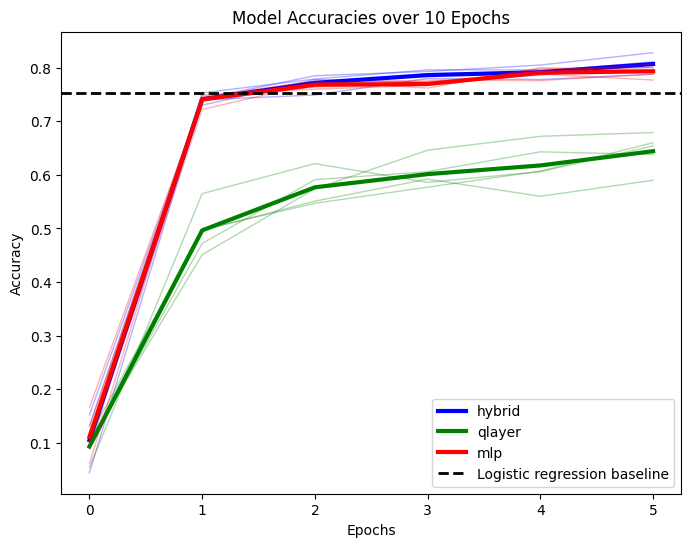

In [13]:
import matplotlib.pyplot as plt

model_accuracies = [hybrid_accs, qlayer_accs, classic_accs]

colors = ['b', 'g', 'r']  # Different colors for each model
labels = ['hybrid', 'qlayer', 'mlp']

plt.figure(figsize=(8, 6))

for model_idx, accuracies in enumerate(model_accuracies):
    accuracies = np.array(accuracies)  # Convert to numpy array (shape: num_runs x num_epochs)
    
    # Plot each individual accuracy curve as a thin line
    for acc in accuracies:
        plt.plot(acc, color=colors[model_idx], alpha=0.3, linewidth=1)  # Thin and transparent

    # Compute and plot the mean accuracy curve in bold
    mean_accuracy = np.mean(accuracies, axis=0)
    plt.plot(mean_accuracy, color=colors[model_idx], linewidth=3, label=labels[model_idx])

baseline_accuracy = 0.753  # Example baseline accuracy

plt.axhline(y=baseline_accuracy, color='k', linestyle='--', linewidth=2, label='Logistic regression baseline')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Accuracies over 10 Epochs")
plt.show()

Low dimensional tests (circles and moons dataset) with qlayer
---

In [17]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import perceval as pcvl
import merlin as ML
from sklearn.datasets import make_circles, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Generate synthetic dataset (two concentric circles)
# X, y = make_circles(n_samples=1000, noise=0.1, factor=0.6, random_state=42)
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# Split dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (important for logistic regression)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test)

Accuracy: 0.85


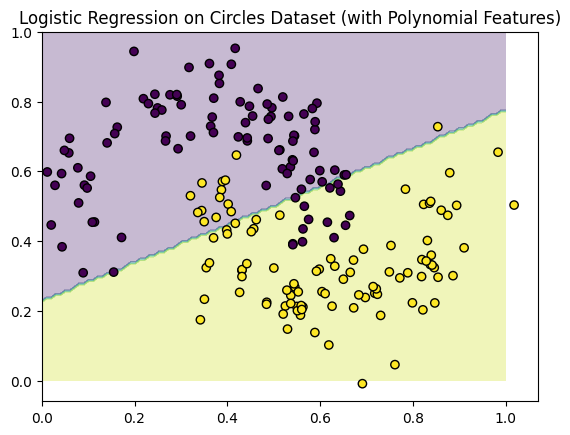

In [18]:
# logistic regression
clf = LogisticRegression(solver='lbfgs', max_iter=200)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
xx, yy = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = clf.predict(grid).reshape(xx.shape)

plt.contourf(xx, yy, probs, alpha=0.3)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k')
plt.title("Logistic Regression on Circles Dataset (with Polynomial Features)")
plt.show()

pytorch parameters 141


Qmodel Accuracy: 0.99


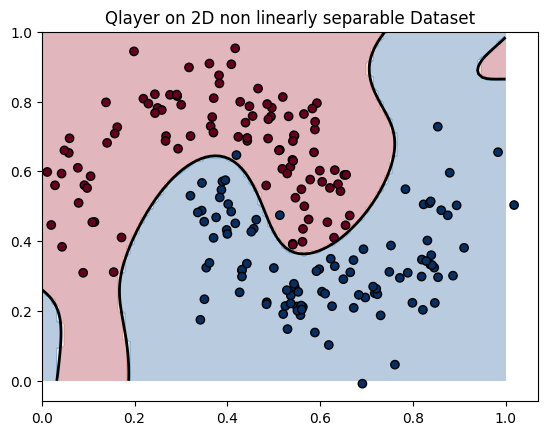

In [33]:
m = 6
d = 2
c = create_circuit(m, d, depth=4)
# thetas = [p.name for p in c.get_parameters() if not p.name.startswith("px")]
input_state = [1, 0] * (m // 2) + [0] * (m % 2)
input_state = pcvl.BasicState(input_state)

model = nn.Sequential(
                ML.QuantumLayer(
                    input_size=d,
                    output_size=1,
                    circuit=c,
                    trainable_parameters=["theta"],                            # Which parameters to train
                    input_parameters=["px"],
                    input_state = input_state,
                    output_mapping_strategy=ML.OutputMappingStrategy.LINEAR),
                nn.Sigmoid()
        )



model_name ='qlayer'
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
print('pytorch parameters', sum(p.numel() for p in model.parameters() if p.requires_grad) )
criterion = nn.BCELoss()
n_epochs = 10
batch_size = 8

losses = []
train_accuracies = []
test_accuracies = []

model.train()
pbar = tqdm(range(n_epochs), leave=False, desc=f"Training {model_name}")
for epoch in pbar:
    model.train()
    permutation = torch.randperm(X_train.size()[0])
    total_loss = 0

    for i in range(0, X_train.size()[0], batch_size):
        indices = permutation[i:i + batch_size]
        batch_x, batch_y = X_train[indices], y_train[indices]

        outputs = model(batch_x)
        outputs = outputs.squeeze(1)
        loss = criterion(outputs, batch_y.float())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / (X_train.size()[0] // batch_size)
    losses.append(avg_loss)
    pbar.set_description(f"Training {model_name} - Loss: {avg_loss:.4f}")

    # Evaluation
    model.eval()
    with torch.no_grad():
        train_outputs = model(X_train)
        train_preds = torch.argmax(train_outputs, dim=1).numpy()
        train_acc = accuracy_score(y_train.numpy(), train_preds)
        train_accuracies.append(train_acc)

        test_outputs = model(X_test)
        test_preds = torch.argmax(test_outputs, dim=1).numpy()
        test_acc = accuracy_score(y_test.numpy(), test_preds)
        test_accuracies.append(test_acc)


# Plot decision boundary
xx, yy = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))
grid = np.c_[xx.ravel(), yy.ravel()]

grid = torch.tensor(grid, dtype=torch.float32)
probs = model(grid).view(100,100)
probs = probs.detach().numpy()
probs.shape, xx.shape

preds = (probs > 0.5).astype(int)

y_preds = model(X_test).detach().numpy()
y_preds = (y_preds > 0.5).astype(int)
accuracy = accuracy_score(y_test, y_preds)
print(f"Qmodel Accuracy: {accuracy:.2f}")

plt.contourf(xx, yy, preds, alpha=0.3, cmap=plt.cm.RdBu)  # Class regions
plt.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2)  # Decision boundary

# Plot test points
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.RdBu, edgecolors='k')
plt.title("Qlayer on 2D non linearly separable Dataset")
plt.show()